In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)

mont_rad_pib["log_pib_mun_trend"] = np.log(mont_rad_pib["pib_mun_trend"])
medidas = mont_rad_pib.drop(["quarter", "fecha", "municipio", "pib_mun_desestacionalizado", "pib_mun_trend", "log_pib_mun_trend"],axis = 1).columns
for col in medidas:
    mont_rad_pib[col] = np.log(mont_rad_pib[col])


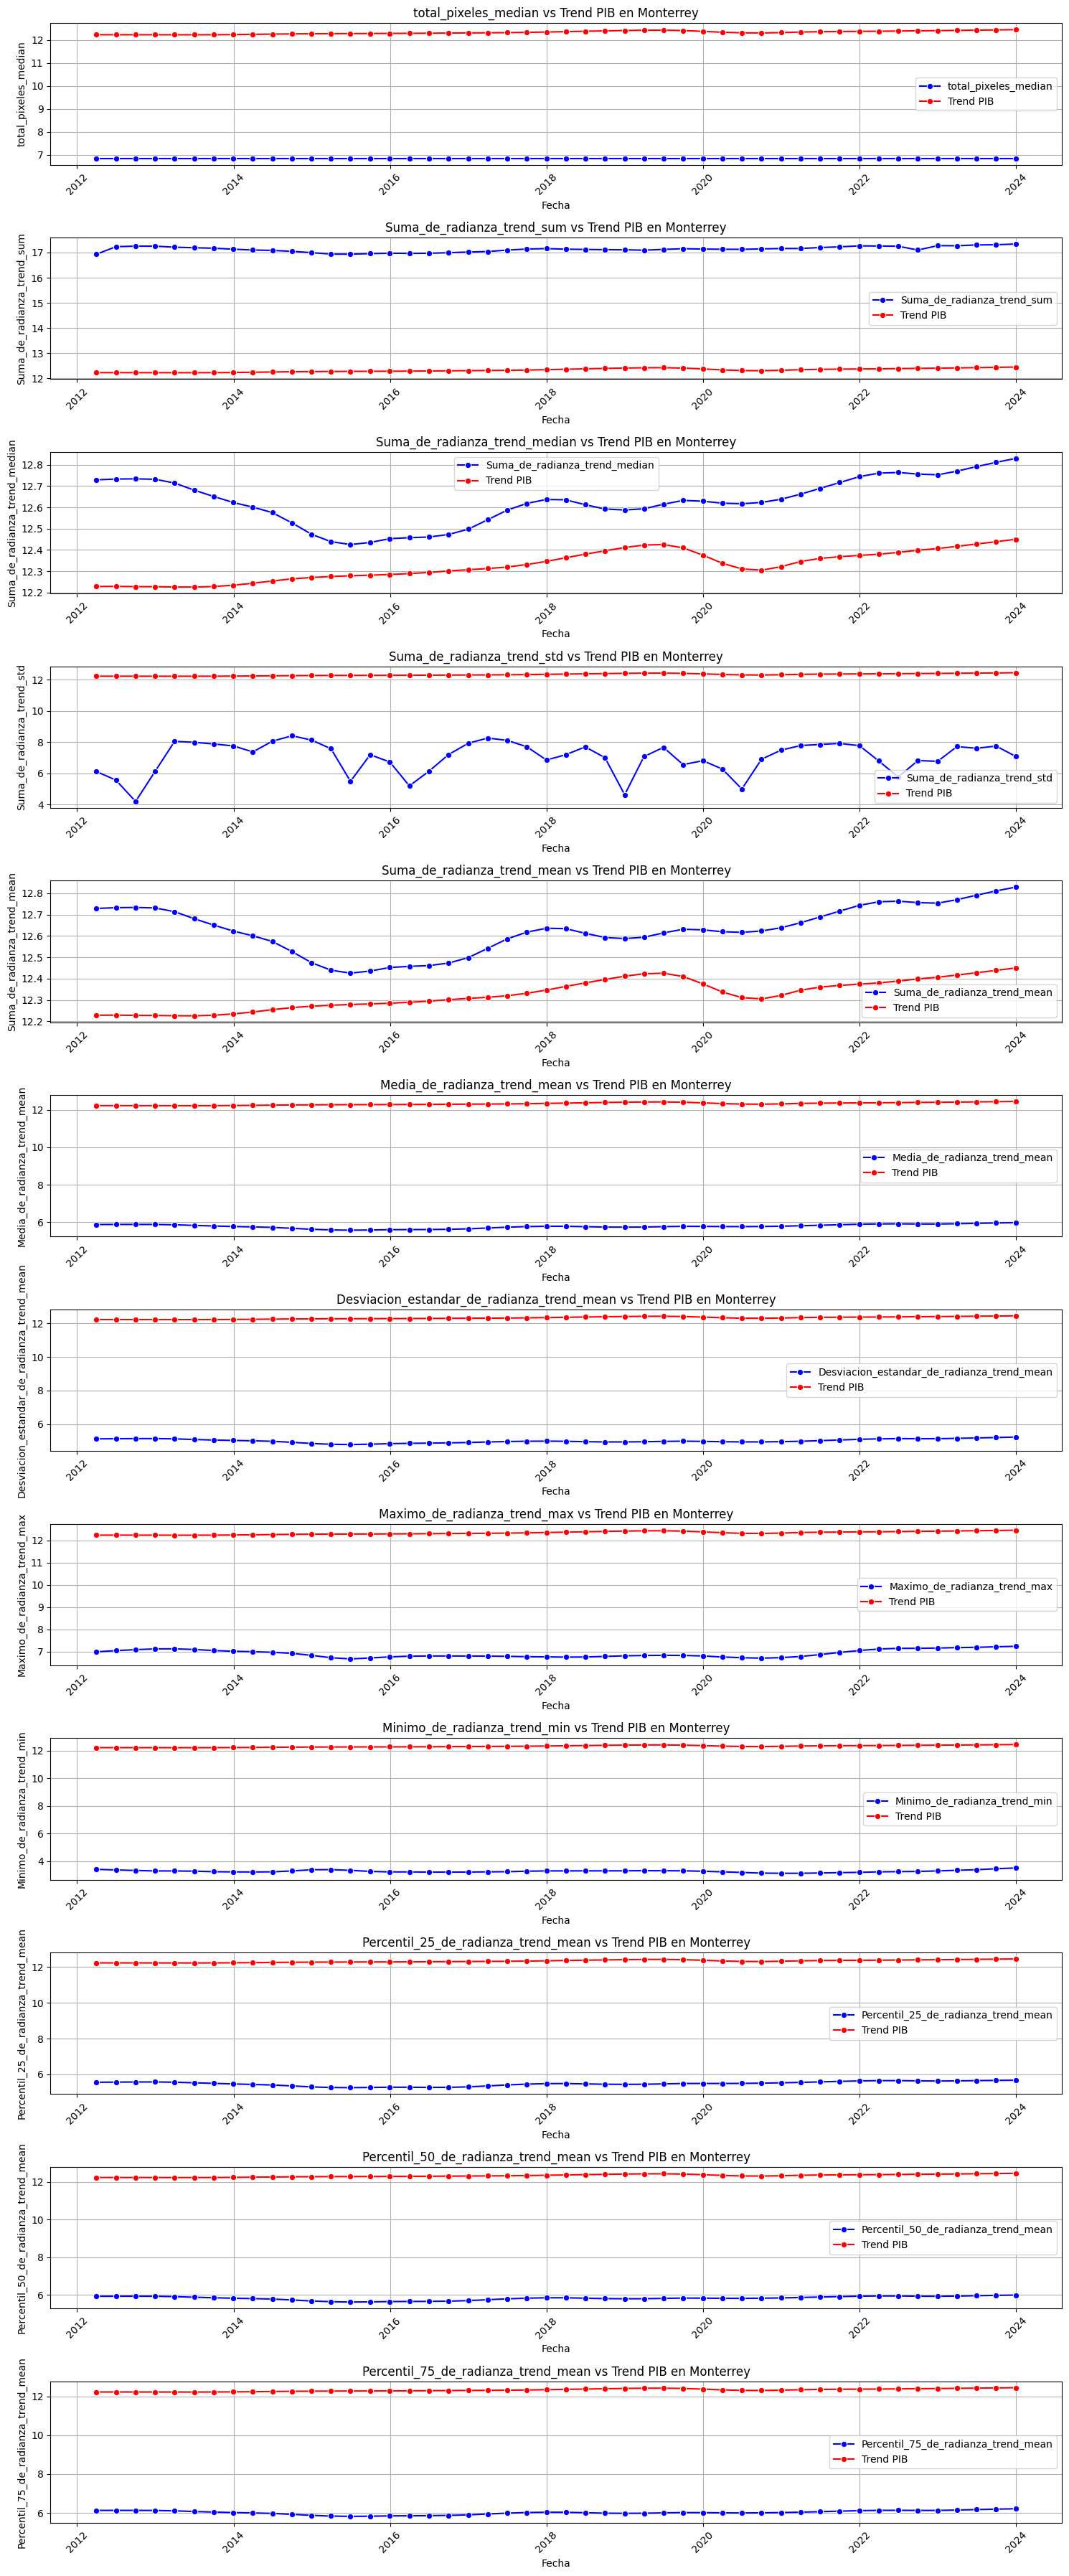

In [133]:
mont_rad_pib.head(1)


fig, axes = plt.subplots(len(medidas), 1, figsize=(15, 3 * len(medidas)), sharex=False)

for i, col in enumerate(medidas):
    sns.lineplot(x = "fecha", y = col, data = mont_rad_pib, ax = axes[i], color = "blue", label = col, marker = "o")
    sns.lineplot(x = "fecha", y = "log_pib_mun_trend", data = mont_rad_pib, ax = axes[i], color = "red", label = "Trend PIB", marker = "o")
    axes[i].set_title(f"{col} vs Trend PIB en Monterrey")
    axes[i].set_xlabel("Fecha")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', which='major', labelrotation=45)
    axes[i].grid(True)
plt.tight_layout()


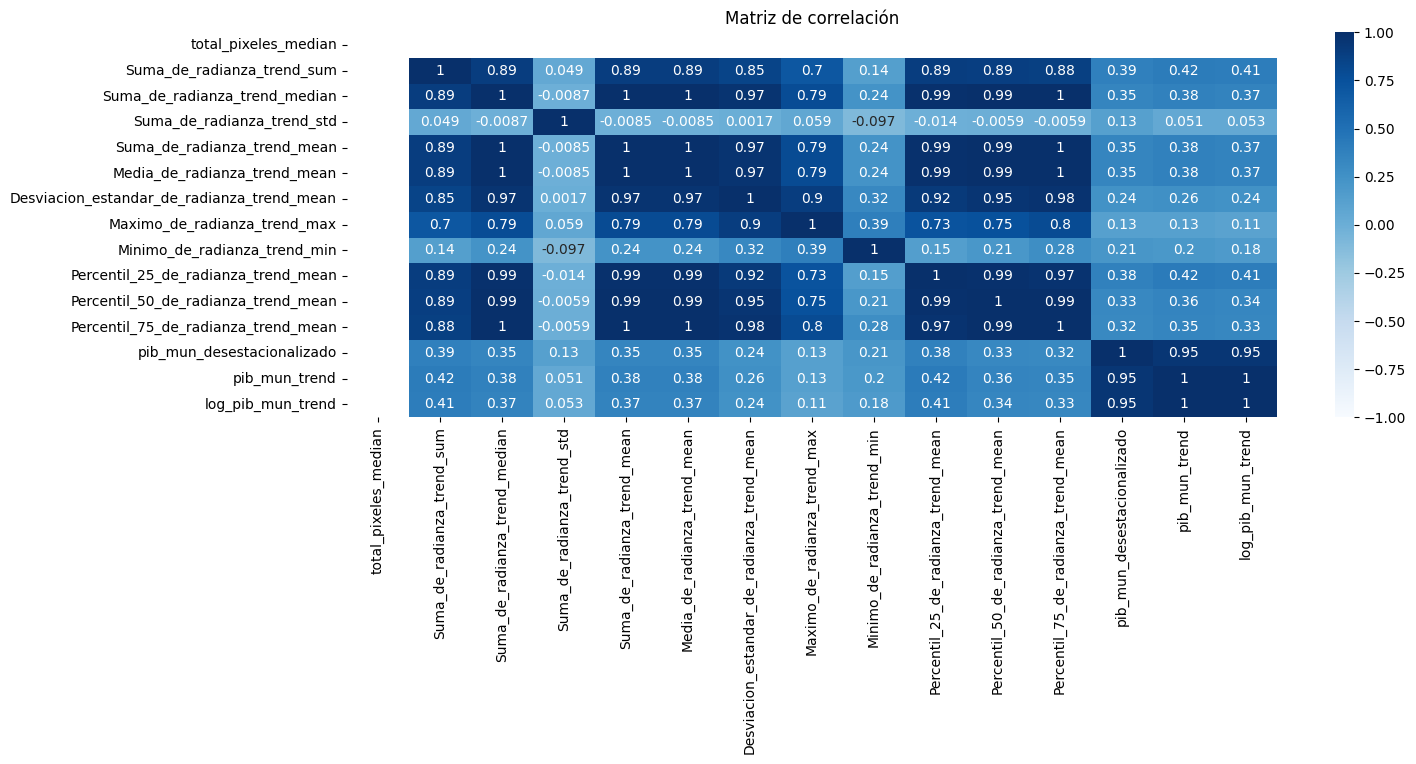

In [134]:
plt.figure(figsize=(15, 5))
corr_matrix = mont_rad_pib.drop(["quarter", "fecha", "municipio"],axis = 1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1, center=0)
plt.title('Matriz de correlación')
plt.show()


In [135]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = mont_rad_pib[medidas]
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif

/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF Factor,features
0,0.000000e+00,total_pixeles_median
1,5.405620e+00,Suma_de_radianza_trend_sum
2,5.462527e+04,Suma_de_radianza_trend_median
3,1.559992e+00,Suma_de_radianza_trend_std
4,inf,Suma_de_radianza_trend_mean
5,inf,Media_de_radianza_trend_mean
6,1.468894e+03,Desviacion_estandar_de_radianza_trend_mean
7,9.916712e+01,Maximo_de_radianza_trend_max
8,8.360079e+00,Minimo_de_radianza_trend_min
9,2.236942e+03,Percentil_25_de_radianza_trend_mean


In [136]:
import pandas as pd
import itertools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def calcular_vif(df, variables):
    X = df[variables]
    X = add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

def generar_combinaciones(variables, min_vars=2, max_vars=None):
    if max_vars is None:
        max_vars = len(variables)
    combinaciones = []
    for r in range(min_vars, max_vars+1):
        combinaciones.extend(list(itertools.combinations(variables, r)))
    return combinaciones

variables = mont_rad_pib[medidas].columns  # lista de variables
combinaciones = generar_combinaciones(variables, min_vars=2, max_vars=4)  # ejemplo hasta 2 variables

resultados = []

for combo in combinaciones:
    try:
        vif = calcular_vif(mont_rad_pib, list(combo))
        max_vif = vif['VIF'][1:].max()  # ignoramos la constante
        
        # Calcular error cuadratico medio (ECM)
        X_model = mont_rad_pib[list(combo)].values
        y_model = mont_rad_pib["log_pib_mun_trend"].values
        lr = LinearRegression()
        lr.fit(X_model, y_model)
        y_pred = lr.predict(X_model)
        ecm = mean_squared_error(y_model, y_pred)
        r2 = lr.score(X_model, y_model)
        
        resultados.append({
            "combinacion": combo,
            "max_vif": max_vif,
            "mse": ecm,
            "r2": r2
        })
    except Exception as e:
        # Captura errores por singularidad (ej. multicolinealidad perfecta)
        resultados.append({
            "combinacion": combo, 
            "max_vif": float('inf'),
            "mse": float('inf'),
            "r2": float('-inf')
        })

resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by = [ "r2"], ascending = [False])
resultados_df

/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/jesusmanuellopezfabian/Documents/ESCOM/Trabajo-Terminal/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/Users/jesusmanuellopezfabian/Documents/ESCOM/Tr

,combinacion,max_vif,mse,r2
643,"(Suma_de_radianza_trend_median, Desviacion_est...",2812.278912,0.001560,0.666610
734,"(Suma_de_radianza_trend_mean, Desviacion_estan...",2702.533565,0.001592,0.659811
754,"(Media_de_radianza_trend_mean, Desviacion_esta...",2702.533565,0.001592,0.659811
647,"(Suma_de_radianza_trend_median, Maximo_de_radi...",228.164189,0.001986,0.575758
738,"(Suma_de_radianza_trend_mean, Maximo_de_radian...",220.040674,0.002005,0.571663
...,...,...,...,...
7,"(total_pixeles_median, Minimo_de_radianza_tren...",1.000000,0.004534,0.031141
33,"(Suma_de_radianza_trend_std, Maximo_de_radianz...",1.003516,0.004615,0.013864
88,"(total_pixeles_median, Suma_de_radianza_trend_...",1.003516,0.004615,0.013864
6,"(total_pixeles_median, Maximo_de_radianza_tren...",1.000000,0.004626,0.011672


# Prueba de linealidad

                            OLS Regression Results                            
Dep. Variable:      log_pib_mun_trend   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     11.19
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           1.79e-08
Time:                        15:46:39   Log-Likelihood:                 94.051
No. Observations:                  48   AIC:                            -166.1
Df Residuals:                      37   BIC:                            -145.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

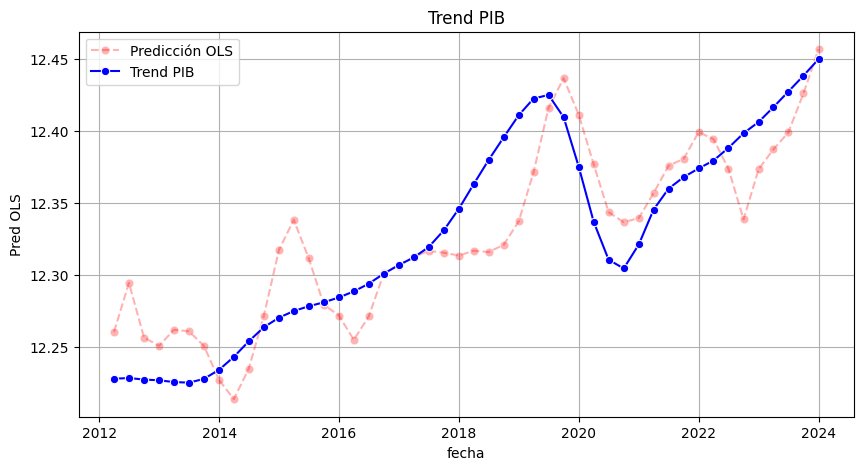

In [137]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Variables independientes (excluyendo columnas no numéricas o que no quieres incluir)
X = mont_rad_pib.drop(columns=["quarter", "fecha", "pib_mun_desestacionalizado", "municipio", "pib_mun_trend", "log_pib_mun_trend"])
if "Pred OLS" in mont_rad_pib.columns:
    X = mont_rad_pib.drop(columns=["quarter", "fecha", "pib_mun_desestacionalizado", "municipio", "pib_mun_trend", "log_pib_mun_trend", "Pred OLS"])

else:
    X = mont_rad_pib.drop(columns=["quarter", "fecha", "pib_mun_desestacionalizado", "municipio", "pib_mun_trend", "log_pib_mun_trend"])

#X = mont_rad_pib[['total_pixeles_median', 'Suma_de_radianza_trend_sum']]
y = mont_rad_pib["log_pib_mun_trend"]

# Escalar las variables X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir de nuevo a DataFrame (opcional, para mantener nombres de columnas)
import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Añadir constante al modelo
X_scaled = sm.add_constant(X_scaled)

# Ajustar modelo OLS
modelo = sm.OLS(y, X_scaled)
resultado = modelo.fit()

print(resultado.summary())

# Guardar predicciones
mont_rad_pib["Pred OLS"] = resultado.predict(X_scaled)

# Graficar
plt.figure(figsize=(10, 5))
sns.lineplot(x="fecha", y="Pred OLS", data=mont_rad_pib, color="red", label="Predicción OLS", marker="o", linestyle="--", alpha=0.3)
sns.lineplot(x="fecha", y="log_pib_mun_trend", data=mont_rad_pib, color="blue", label="Trend PIB", marker="o")
plt.legend()
plt.title("Trend PIB")
plt.grid(True)
plt.show()



# Notas:

- Cond. No.: Valor extremadamente alto, esto indica multicolinealidad severa en las variables explicativas.
- Durbin-watson: Valor muy bajo,indicando una fuerte correlación positiva de los residuos ** Viola un supuesto de la OLS **
- Omnibus y Prob(Omnibus): Parece que los residuos son aproximadamente normales
- Skew: Ligeramente positivo, los residuos tienen una asimetría leve hacia la derecha
- Kurosis: Cercano a 3, los residuos no tienen colas

# RESET TEST

In [138]:
reset_test = linear_reset(resultado)
print(reset_test)

<Wald test (chi2): statistic=2.4404913494544442, p-value=0.2951576452420245, df_denom=2>


P-value = 0.295 > 0.05, no rechazamos la hipótesis nula, es decir, el modelo lineal no muestra evidencia de errores de especificación importantes

# Residuos

In [139]:
residuals = resultado.resid
print("Suma de residuos:", round(residuals.sum(), 5))
print("Media de residuos:", round(residuals.mean(), 5))


Suma de residuos: -0.0
Media de residuos: -0.0


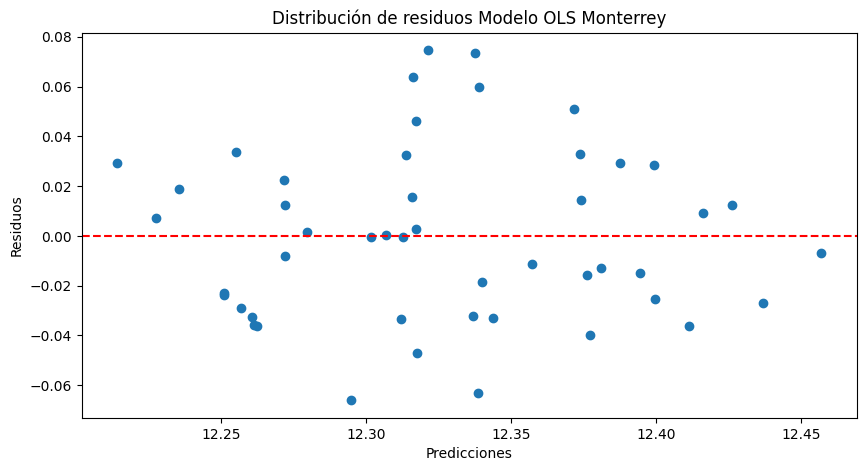

In [140]:
plt.figure(figsize=(10, 5))
plt.scatter(resultado.predict(X_scaled), resultado.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Distribución de residuos Modelo OLS Monterrey")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()


- No hay un patrón evidente en los residuos
- La dispersión de los puntos es constante

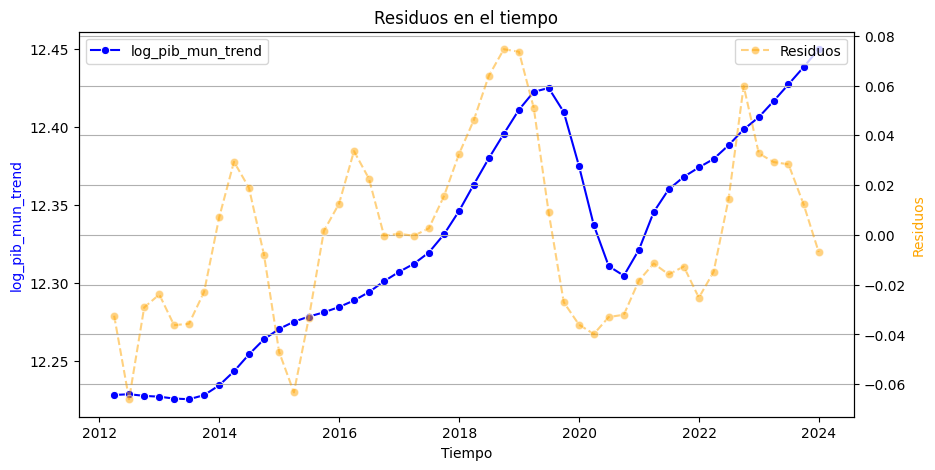

In [141]:
# Residuos en el tiempo (con eje secundario)
monterrey_residuos = mont_rad_pib.copy()
monterrey_residuos["residuos"] = resultado.resid

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
sns.lineplot(x="fecha", y="log_pib_mun_trend", data=monterrey_residuos, ax=ax1, color='b', label="log_pib_mun_trend", marker = "o")
ax1.set_xlabel("Tiempo")
ax1.set_ylabel("log_pib_mun_trend", color='b')
ax2 = ax1.twinx()
sns.lineplot(x="fecha", y="residuos", data=monterrey_residuos, ax=ax2, color='orange', label="Residuos", linestyle = "--", marker = "o", alpha = 0.5)
ax2.set_ylabel("Residuos", color='orange')
plt.title("Residuos en el tiempo")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True)
plt.show()


((array([-2.18794508, -1.81466696, -1.5940389 , -1.43152593, -1.29991017,
         -1.18761792, -1.08858668, -0.99921942, -0.91719469, -0.84091983,
         -0.76924975, -0.7013297 , -0.63650166, -0.57424545, -0.51414026,
         -0.45583845, -0.39904728, -0.34351563, -0.28902427, -0.23537844,
         -0.18240202, -0.12993297, -0.07781945, -0.02591656,  0.02591656,
          0.07781945,  0.12993297,  0.18240202,  0.23537844,  0.28902427,
          0.34351563,  0.39904728,  0.45583845,  0.51414026,  0.57424545,
          0.63650166,  0.7013297 ,  0.76924975,  0.84091983,  0.91719469,
          0.99921942,  1.08858668,  1.18761792,  1.29991017,  1.43152593,
          1.5940389 ,  1.81466696,  2.18794508]),
  array([-0.06604235, -0.06329718, -0.04705259, -0.0398596 , -0.03628814,
         -0.03602747, -0.035701  , -0.03339621, -0.03301156, -0.03247979,
         -0.03209568, -0.02914852, -0.02706492, -0.0252358 , -0.0239523 ,
         -0.02290549, -0.01834503, -0.01587672, -0.01481992, -

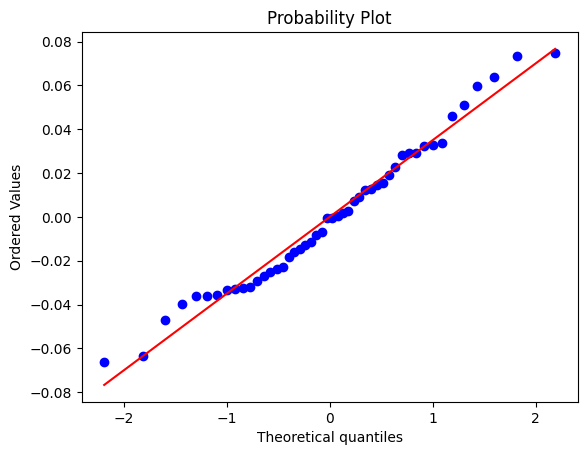

In [142]:
stats.probplot(resultado.resid, dist="norm", plot=plt)

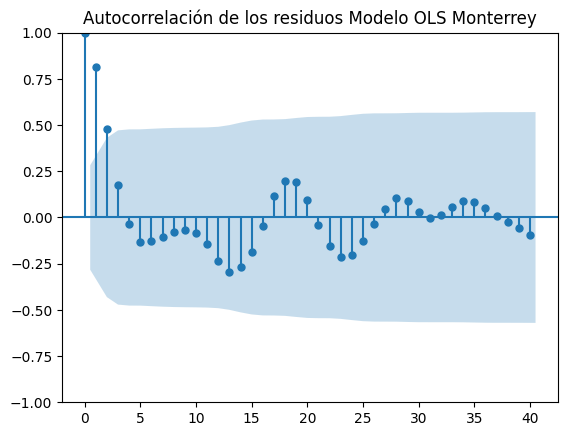

In [143]:
# Autocorrelación de los residuos
plot_acf(resultado.resid, lags=40, ax=plt.gca())
plt.title("Autocorrelación de los residuos Modelo OLS Monterrey")
plt.show()

Los residuos estan autocorrelacionados, Un error positivo en un periodo de tiempo hace muy probable que el modelo también subestime el valor en el siguiente periodo

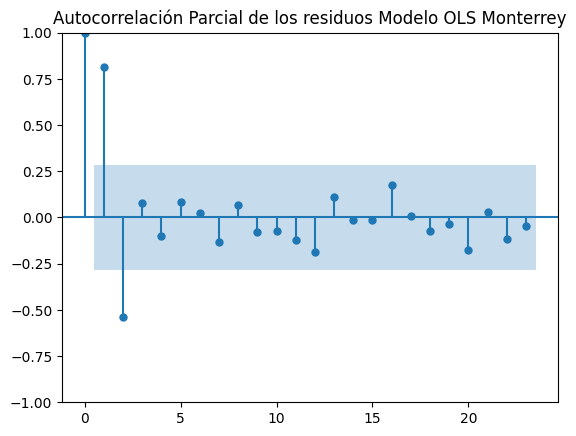

In [145]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(resultado.resid, lags=23, ax=plt.gca())
plt.title("Autocorrelación Parcial de los residuos Modelo OLS Monterrey")
plt.show()


Siguiere que el modelo necesita considerar un componente autoregresivo de orden 2 AR(2)

# TODO:
- Revisar Supuestos OLS
- Probar OLS, RF, SVM y XGBoost
- Probar mismos modelos con dimensión de tiempo
- Pobar mismos modelos con lags